# CrossLS: Surface Code × PQRM Lattice Surgery

**Protocol overview**

CrossLS merges an unrotated surface code patch with a Punctured Quantum Reed-Muller (PQRM) code patch via a ZZ lattice surgery coupler. The key motivation:
- The **surface code** provides efficient, scalable memory and Clifford gates.
- The **PQRM** code supports a transversal non-Clifford gate (T gate and smaller-angle rotations), enabling magic-state injection without distillation.
- The **lattice surgery merge** teleports the logical state between the two codes via d round of ZZ/XX measurements.

## Supported PQRM parameters

| (rx, rz, m) | Code params | Data qubits | Z-stab count | Logical Z weight |
|-------------|-------------|-------------|--------------|------------------|
| (1, 2, 4)   | [[15, 1, 3]] | 15         | 11           | 3                |
| (1, 3, 5)   | [[31, 1, 5]] | 31         | 26           | 7                |
| (1, 4, 6)   | [[63, 1, 7]] | 63         | 57           | 7                |

X stabilizers of PQRM are **post-selected** only (no syndrome ancilla), avoiding the high-weight stabilizer measurements at the cost of a post-selection rate.

## Post-selection modes

- **`pqrm_only`**: post-select on PQRM X-stabilizer violations only.
- **`hybrid`**: post-select on both PQRM X-stabilizer violations and surface code SE errors (stricter, higher rejection rate, lower residual LER).


In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.cross_ls import CrossLSExperiment
from lightstim.noise.config import NoiseConfig

## 1. Build Circuit

In [2]:
PQRM_para  = [1, 2, 4]   # [[15,1,3]]; try [1,3,5] or [1,4,6]
d_surf     = 3 # try d_surf=3,4,5,6,7 
rounds     = 2 # use rounds=d_surf for better fault-tolerance, here rounds=2 for simpler visualization
PQRM_state = 'Z'   # logical state injected into PQRM side; 'Z', 'X', or 'Y'

exp = CrossLSExperiment(
    PQRM_para=PQRM_para,
    d_surf=d_surf,
    rounds=rounds,
    PQRM_state=PQRM_state,
    surf_state='X',
    if_detector=True,
    post_select_hybrid=True,   # hybrid post-selection (paper setting)
)

with contextlib.redirect_stdout(io.StringIO()):
    circuit = exp.build()

print(f'PQRM{tuple(PQRM_para)}  d_surf={d_surf}  rounds={rounds}  state={PQRM_state}')
print(f'  num_qubits:      {circuit.num_qubits}')
print(f'  num_detectors:   {circuit.num_detectors}')
print(f'  num_observables: {circuit.num_observables}')

PQRM(1, 2, 4)  d_surf=3  rounds=2  state=Z
  num_qubits:      55
  num_detectors:   63
  num_observables: 1


## 2. Noiseless Sanity Check

In [3]:
import numpy as np

sampler = circuit.compile_detector_sampler()
dets, obs = sampler.sample(shots=500, separate_observables=True)
print(f'Noiseless: det errors={np.any(dets)}, obs errors={np.any(obs)}')

Noiseless: det errors=False, obs errors=False


## 3. Circuit Diagram

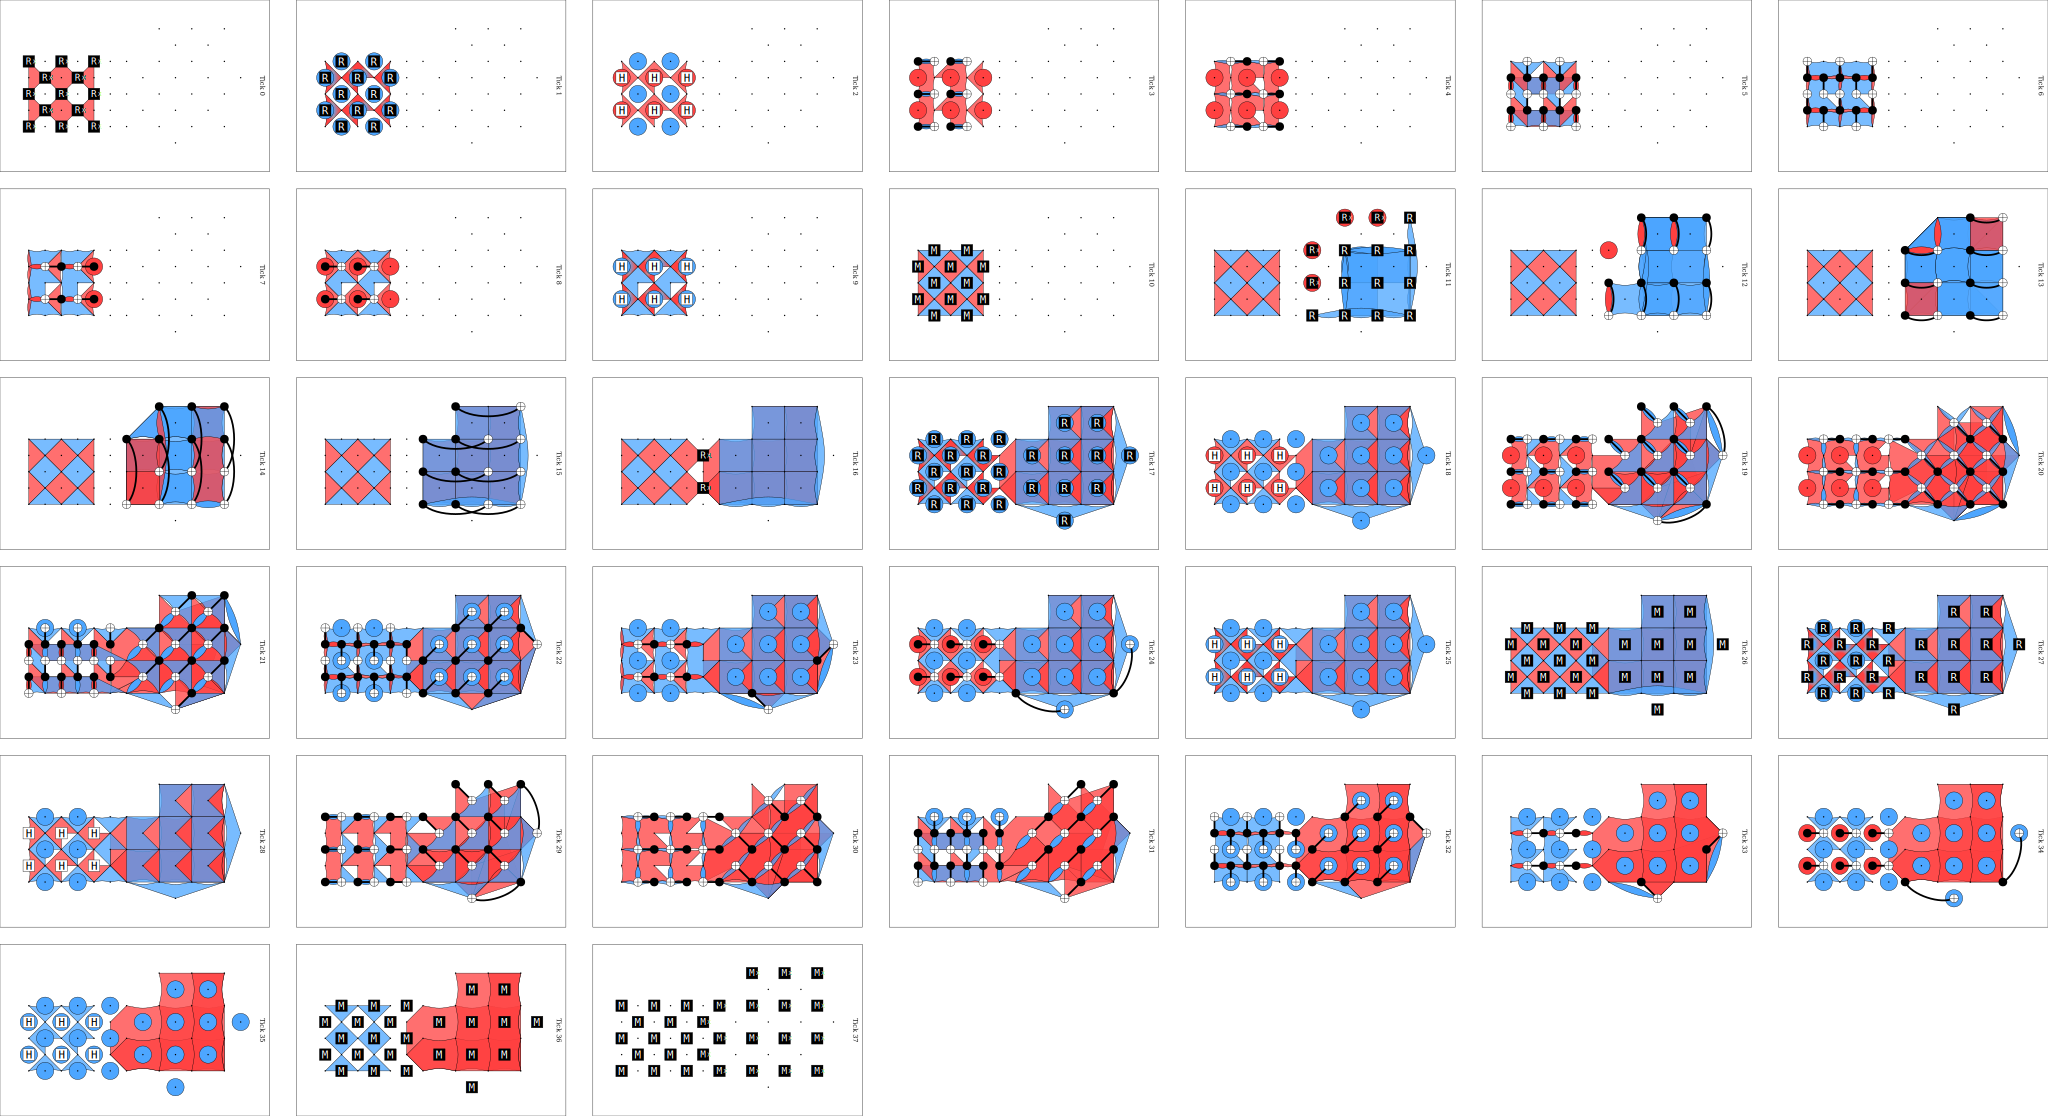

In [4]:
circuit.diagram('detslice-with-ops-svg')

## 4. Noise Model and Simulation

Noise model: **circuit-level** — p_1q = p_2q = p_meas = p_reset = p.

Post-selection is handled inside `CrossLSExperiment`: the noisy circuit already contains DETECTOR instructions that flag PQRM X-stabilizer violations (and optionally surface SE errors in hybrid mode). The `SimulationPipeline` discards shots where any flagged detector fires.

**Decoder note**: CrossLS uses **MWPF** (not PyMatching).  
In PQRM, a single error may flip more than two detectors and create hyperedges that PyMatching cannot decompose; MWPF handles hyperedges natively.

In [5]:
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

p = 1e-3
rounds = d_surf

exp_noisy = CrossLSExperiment(
    PQRM_para=PQRM_para,
    d_surf=d_surf,
    rounds=rounds,
    PQRM_state=PQRM_state,
    surf_state='X',
    if_detector=True,
    post_select_hybrid=True,
    noise_params=NoiseConfig(p_1q=1e-6, p_2q=p, p_meas=p, p_reset=p),
    noise_model='circuit_level',
)

with contextlib.redirect_stdout(io.StringIO()):
    noisy_circuit = exp_noisy.build()

# Count post-select detectors (those flagging PQRM X-stab violations)
n_det = noisy_circuit.num_detectors
n_obs = noisy_circuit.num_observables
print(f'Noisy circuit: {n_det} detectors, {n_obs} observables')

Noisy circuit: 88 detectors, 1 observables


In [6]:
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig


pipeline = SimulationPipeline(
    decoder_config=DecoderConfig('mwpf'),
    max_shots=200_000,
    max_errors=50,
    batch_size=10_000,
    num_workers=4,
    print_progress=True,
    progress_interval_sec=5.0,
)

stats = pipeline.run(noisy_circuit)
print(f'\np={p:.0e}  LER={stats.logical_error_rate:.2e}  '
      f'PS_rate={stats.post_selection_rate:.2f}  '
      f'({stats.errors}/{stats.post_selected_shots:,})')

shots=0 kept=0 errors=0 LER=0.00e+00±-- elapsed=0.0s ETA=--

final shots=200,000 kept=162,883 errors=41 LER=2.52e-04±7.70e-05 elapsed=19.1s ETA=0s

p=1e-03  LER=2.52e-04  PS_rate=0.81  (41/162,883)
